In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.shape

(2240, 22)

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

##  Handling missing values

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Feature engineering 

In [7]:
# Age 
df["Age"] = 2026 - df["Year_Birth"]

In [8]:
# Customer joining date 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_date"] = (reference_date - df["Dt_Customer"]).dt.days

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_date'],
      dtype='object')

In [10]:
# Spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [11]:
# Children 

df["Total_Children"] = df["Teenhome"] + df["Kidhome"]

In [12]:
# Education 
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergrad" , "2n Cycle":"Undergrad" ,
    "Graduation":"Graduate" ,
    "PhD":"Postgraduate" , "Master":"Postgraduate"
})

In [13]:
# Marital_Status

df["Living_with"] = df["Marital_Status"].replace({
    "Married":"Partner" , "Together" : "Partner",
    "Single":"Alone" , "Divorced":"Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

## Dropping Columns

In [14]:
amt_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols = ["ID","Kidhome" ,"Teenhome","Year_Birth","Marital_Status","Dt_Customer"]

total_cols = amt_cols + cols

df_cleaned = df.drop(columns=total_cols)

In [15]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_date,Total_Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [16]:
df_cleaned.shape

(2240, 15)

## Outliers

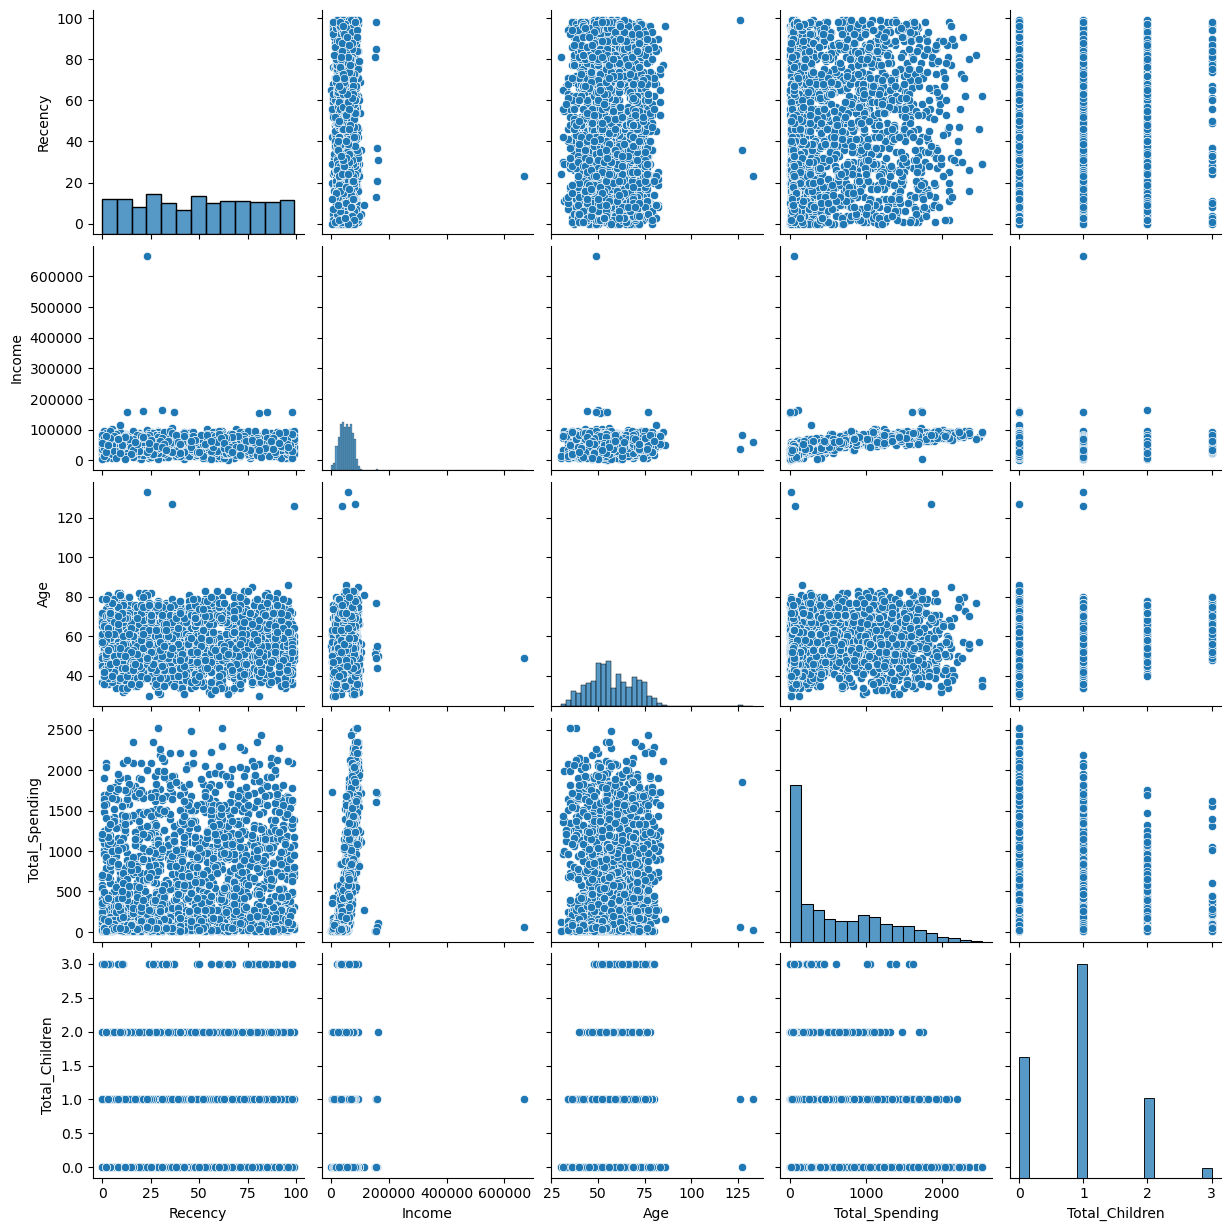

In [17]:
cols = ["Recency","Income","Age","Total_Spending","Total_Children"]

# Realtive plot of some (features) --- pair plots
sns.pairplot(df_cleaned[cols])

In [18]:
# remove outlier 
print("Datasize with outliers :" , len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000)]

print("Datasize without outliers :" , len(df_cleaned))

Datasize with outliers : 2240
Datasize without outliers : 2236


## Heatmap

<Axes: >

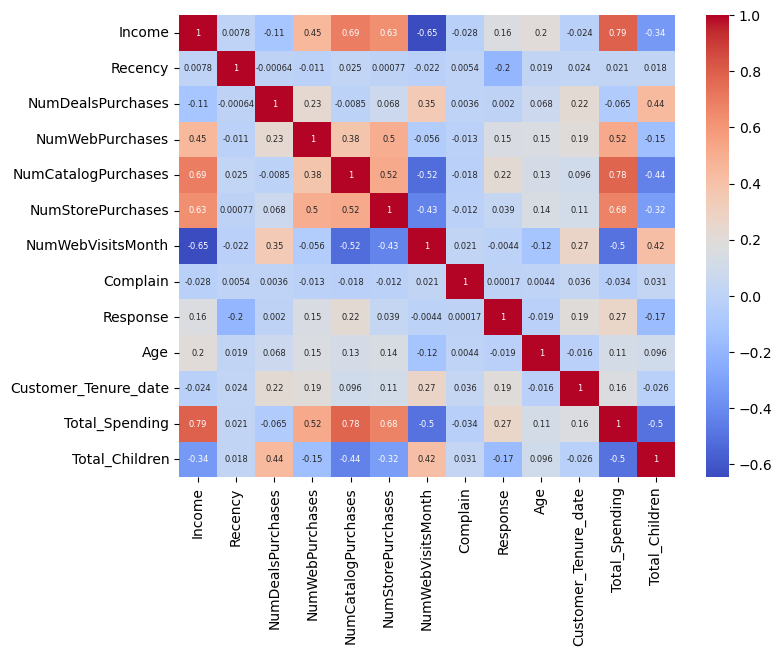

In [19]:
corr = df_cleaned.corr(numeric_only = True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size":6},
    cmap='coolwarm'
)

## One-hot encoding 

In [20]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
ohe = OneHotEncoder()

cat_col = ["Education" , "Living_with"]

enc_col = ohe.fit_transform(df_cleaned[cat_col])

In [22]:
enc_df = pd.DataFrame(enc_col.toarray(), columns=ohe.get_feature_names_out(cat_col),index=df_cleaned.index)

In [23]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_col),enc_df],axis=1)

In [24]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_date,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergrad,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [25]:
df_encoded.shape

(2236, 18)

## Encoding 

In [26]:
X = df_encoded

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualisation

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [29]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

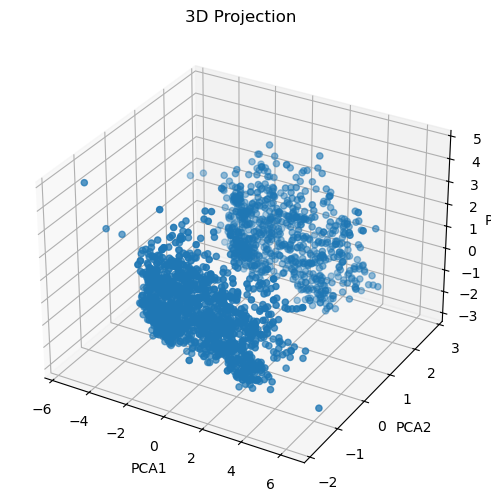

In [30]:
# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.title("3D Projection")

## <u>Analyze k value<u>

### 1. Elbow Method

In [31]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

In [35]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [36]:
knee = KneeLocator(range(1,11), wcss, curve='convex',direction='decreasing')
optimal_k = knee.elbow

In [37]:
print("Best k value : " , optimal_k)

Best k value :  4


Text(0, 0.5, 'wcss')

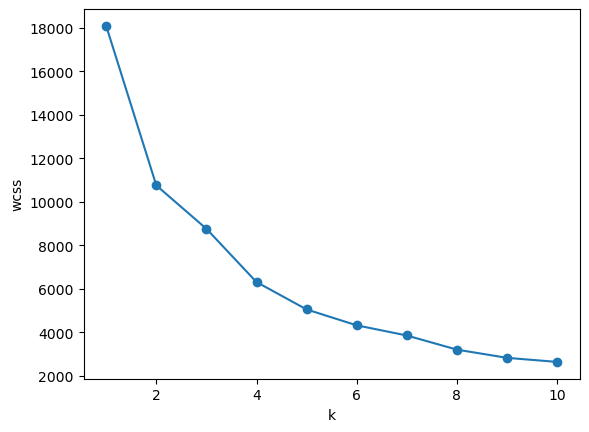

In [38]:
# plot
plt.plot(range(1,11) ,wcss,marker='o')
plt.xlabel("k")
plt.ylabel("wcss")

### 2.Silhoutte score

Text(0, 0.5, 'silhouette_scores')

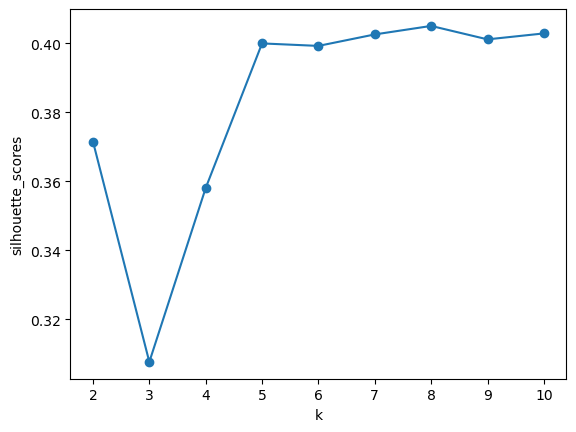

In [39]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)

# plot
plt.plot(range(2,11) ,scores,marker='o')
plt.xlabel("k")
plt.ylabel("silhouette_scores")

Text(0, 0.5, 'SS')

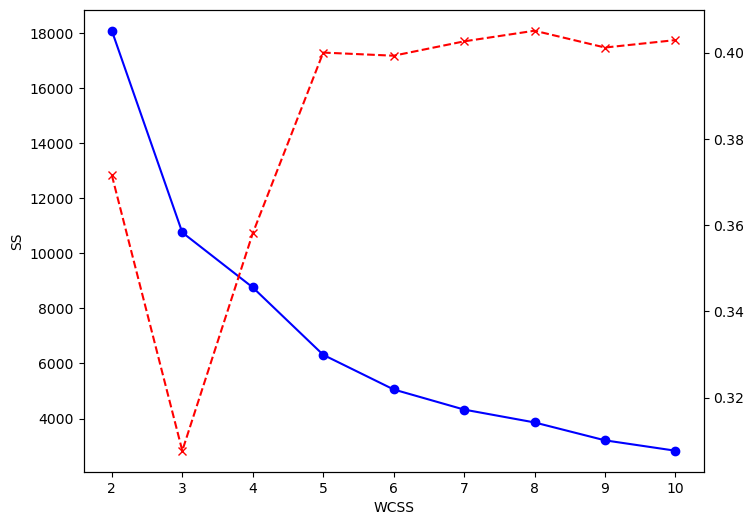

In [40]:
# Combined plot
k_range = range(2,11)

fig , ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range ,wcss[:len(k_range)] ,marker="o" ,color="blue")
ax1.set_xlabel("K")
ax1.set_xlabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range ,scores[:len(k_range)] ,marker="x" ,color="red",linestyle="--")
ax1.set_ylabel("SS")

### Clustering

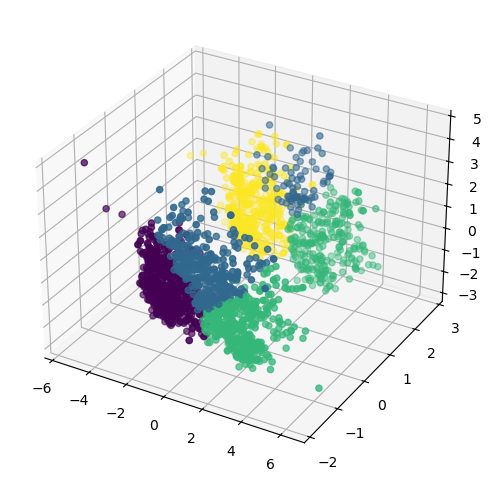

In [41]:
# kmeans clustering 
kmeans = KMeans(n_clusters=4,random_state=42)
kmean_label = kmeans.fit_predict(X_pca)

# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2] , c=kmean_label)

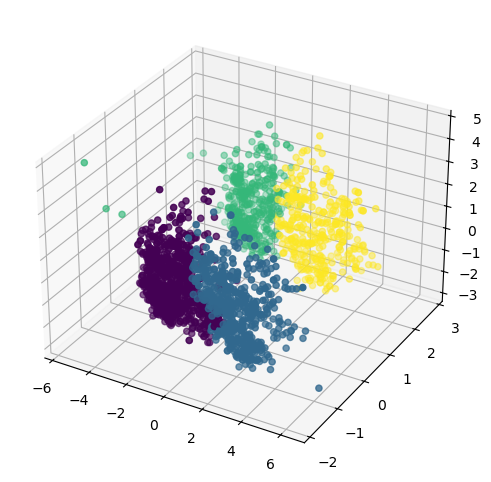

In [42]:
# Agglomerative clustering 
from sklearn.cluster import AgglomerativeClustering

agl = AgglomerativeClustering(n_clusters=4 , linkage='ward')
agl_label = agl.fit_predict(X_pca)

# plot
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2] ,c=agl_label)

### Characterization of clusters 

In [43]:
X["Clusters"] = agl_label

In [44]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_date,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergrad,Living_with_Alone,Living_with_Partner,Clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Clusters', ylabel='count'>

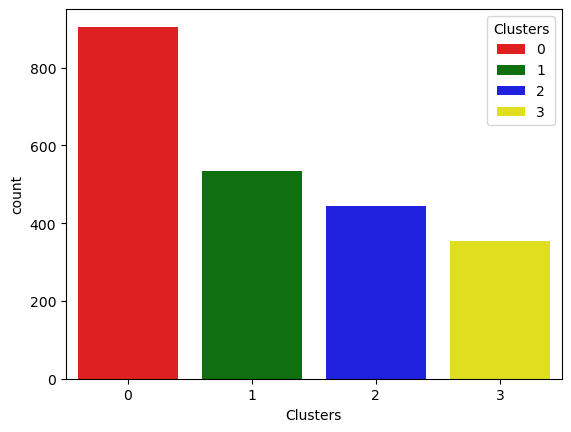

In [45]:
palette = ["red","green","blue","yellow"]

sns.countplot(x=X["Clusters"], palette=palette,hue=X["Clusters"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

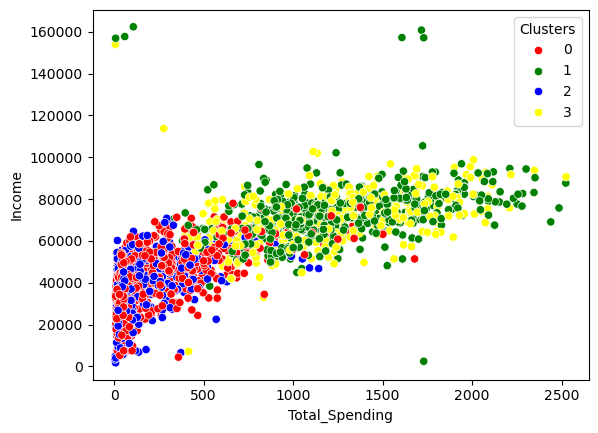

In [46]:
# Income & Spending pattern

sns.scatterplot(x=X["Total_Spending"],y=X["Income"],palette=palette,hue=X["Clusters"])

In [47]:
# Cluster Summary

cluster_summary = X.groupby("Clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
Clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_date  Total_Spending  \
Clu